# Data Preparation & Initialization

### Set Gobal Seed

In [71]:
Seed = 1

### Import Data

In [72]:
import pandas as pd

df = pd.read_csv("packet-data/normalized_original_data.csv")

df.head()

,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,handshake_cipher_suites_length,handshake_ciphersuites,...,highest_layer_STUN,highest_layer_TCP,highest_layer_TLS,highest_layer_TPLINK-SMARTHOME,highest_layer_UDP,highest_layer_UDPENCAP,highest_layer_XML,highest_layer__WS.MALFORMED,id,label
0,0.824115,1.0,0.0,0.0,1.041916,-0.048780,-0.331699,-0.795316,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,benign
1,0.008429,-1.0,0.0,0.0,0.000000,8.780488,0.531342,0.216408,0.0,0.0,...,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,2,benign
2,0.216425,1.0,0.0,0.0,-0.053892,-0.048780,0.073130,-0.795316,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,benign
3,-0.148788,-1.0,0.0,0.0,0.000000,8.780488,0.531342,0.216590,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,benign
4,0.746796,1.0,0.0,0.0,1.035928,0.237805,-0.333876,0.146365,0.0,0.0,...,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,5,benign


### Drop Variables Not Used
- Drop "id" column

In [73]:
# Preserve IDs for linking Phase 2 alerts to Phase 3 flow records.
packet_ids = df["id"].copy() if "id" in df.columns else pd.Series(df.index)

# ID is an identifier, not a behavioral feature.
df = df.drop(columns=["id"], errors="ignore")

df.head()

,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,handshake_cipher_suites_length,handshake_ciphersuites,...,highest_layer_STP,highest_layer_STUN,highest_layer_TCP,highest_layer_TLS,highest_layer_TPLINK-SMARTHOME,highest_layer_UDP,highest_layer_UDPENCAP,highest_layer_XML,highest_layer__WS.MALFORMED,label
0,0.824115,1.0,0.0,0.0,1.041916,-0.048780,-0.331699,-0.795316,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
1,0.008429,-1.0,0.0,0.0,0.000000,8.780488,0.531342,0.216408,0.0,0.0,...,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,benign
2,0.216425,1.0,0.0,0.0,-0.053892,-0.048780,0.073130,-0.795316,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
3,-0.148788,-1.0,0.0,0.0,0.000000,8.780488,0.531342,0.216590,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,benign
4,0.746796,1.0,0.0,0.0,1.035928,0.237805,-0.333876,0.146365,0.0,0.0,...,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0,benign


### Create Data Matrix and Label Vector

In [74]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate labels for stratification and evaluation; labels are never passed to fit().
X = df.drop(columns=["label"]).to_numpy()
y = df["label"].to_numpy()

print("Data matrix shape:", X.shape)
print("Label vector shape:", y.shape)

row_indices = np.arange(X.shape[0])
X_train, X_remaining, y_train, y_remaining, index_train, index_remaining = train_test_split(
    X, y, row_indices, test_size=0.4, stratify=y, random_state=Seed
)
X_validation, X_test, y_validation, y_test, index_validation, index_test = train_test_split(
    X_remaining,
    y_remaining,
    index_remaining,
    test_size=0.5,
    stratify=y_remaining,
    random_state=Seed,
)

# Fit preprocessing only on the training partition.
phase2_scaler = StandardScaler()
X_train_scaled = phase2_scaler.fit_transform(X_train)
X_validation_scaled = phase2_scaler.transform(X_validation)
X_test_scaled = phase2_scaler.transform(X_test)

print("Train/validation/test sizes:", X_train.shape[0], X_validation.shape[0], X_test.shape[0])
print("Training labels are retained only for analysis, not model fitting.")

Data matrix shape: (195940, 164)
Label vector shape: (195940,)
Train/validation/test sizes: 117564 39188 39188
Training labels are retained only for analysis, not model fitting.


# K-means (high-recall alert generator)

### K-means Hyperparameters Tuning
- Hyperparameters:
    - K: number of clusters used to represent benign behaviour
    - Threshold_percentile: distance cutoff for classifying a sample as anomalous

- Model selection uses validation results 
    - recall >= 0.8 and FPR <= 0.1
    - if non qualify
    - keep configuration with FPR <= 0.1


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score)

k_values = [2, 4, 6, 8, 10, 15, 20]
threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

# Fit K-means on unlabeled training features; labels are used only for validation.
X_kmeans_train = X_train_scaled
X_evaluation = X_validation_scaled
y_evaluation = y_validation
y_attack = y_validation[y_validation != "benign"]
true_attack = y_evaluation != "benign"

models = {}
thresholds = {}
inertias = []
kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        random_state=Seed,
    )
    model.fit(X_kmeans_train)

    # A sample is anomalous when its nearest-centroid distance exceeds
    # the chosen percentile of benign training distances.
    training_distances = model.transform(X_kmeans_train).min(axis=1)
    evaluation_distances = model.transform(X_evaluation).min(axis=1)

    models[k] = model
    inertias.append(model.inertia_)

    for percentile in threshold_percentiles:
        threshold = np.percentile(training_distances, percentile)
        predicted_attack = evaluation_distances > threshold

        precision = precision_score(true_attack, predicted_attack, zero_division=0)
        recall = recall_score(true_attack, predicted_attack, zero_division=0)
        f1 = f1_score(true_attack, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        thresholds[(k, percentile)] = threshold
        kmeans_results.append({
            "k": k,
            "threshold_percentile": percentile,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "fpr": fpr,
            "fnr": fnr,
        })

        print(
            f"k={k}, percentile={percentile}: Precision={precision:.4f}, "
            f"Recall={recall:.4f}, F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack)):
            attack_mask = y_evaluation == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

kmeans_results_df = pd.DataFrame(kmeans_results)
display(
    kmeans_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

# Prefer high recall for Phase 2, while limiting validation false alarms.
eligible_kmeans = kmeans_results_df[
    (kmeans_results_df["recall"] >= 0.80) & (kmeans_results_df["fpr"] <= 0.10)
]
if eligible_kmeans.empty:
    eligible_kmeans = kmeans_results_df[kmeans_results_df["fpr"] <= 0.10]
if eligible_kmeans.empty:
    eligible_kmeans = kmeans_results_df
best_kmeans_config = eligible_kmeans.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]

best_k = int(best_kmeans_config["k"])
best_kmeans_percentile = int(best_kmeans_config["threshold_percentile"])
best_kmeans_model = models[best_k]
best_kmeans_threshold = thresholds[(best_k, best_kmeans_percentile)]
kmeans_test_scores = best_kmeans_model.transform(X_test_scaled).min(axis=1)
kmeans_test_predictions = kmeans_test_scores > best_kmeans_threshold
kmeans_test_truth = y_test != "benign"
kmeans_test_precision = precision_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_test_recall = recall_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_test_f1 = f1_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_tn, kmeans_fp, kmeans_fn, kmeans_tp = confusion_matrix(
    kmeans_test_truth, kmeans_test_predictions, labels=[False, True]
).ravel()
kmeans_test_fpr = kmeans_fp / (kmeans_fp + kmeans_tn)
kmeans_test_fnr = kmeans_fn / (kmeans_fn + kmeans_tp)
kmeans_test_roc_auc = roc_auc_score(kmeans_test_truth, kmeans_test_scores)
kmeans_test_pr_auc = average_precision_score(kmeans_test_truth, kmeans_test_scores)
print(
    f"Final K-means test: k={best_k}, percentile={best_kmeans_percentile}, "
    f"Precision={kmeans_test_precision:.4f}, Recall={kmeans_test_recall:.4f}, "
    f"F1={kmeans_test_f1:.4f}, FPR={kmeans_test_fpr:.4f}, "
    f"FNR={kmeans_test_fnr:.4f}, ROC-AUC={kmeans_test_roc_auc:.4f}, "
    f"PR-AUC={kmeans_test_pr_auc:.4f}"
)
print(np.array([[kmeans_tp, kmeans_fp], [kmeans_fn, kmeans_tn]]))
for attack in sorted(np.unique(y_test[y_test != "benign"])):
    attack_mask = y_test == attack
    print(f"  {attack} detection rate: {kmeans_test_predictions[attack_mask].mean():.4f}")

kmeans_alerts_df = pd.DataFrame({
    "packet_id": packet_ids.iloc[index_test].to_numpy(),
    "true_label": y_test,
    "anomaly_score": kmeans_test_scores,
    "alert": kmeans_test_predictions,
})
kmeans_alerts_df = kmeans_alerts_df[kmeans_alerts_df["alert"]].reset_index(drop=True)

k=2, percentile=80: Precision=0.0761, Recall=0.5067, F1=0.1323
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  602  7312]
 [  586 30688]]
  brute_force detection rate: 0.2532
  ddos detection rate: 0.7806
  dns_spoofing detection rate: 0.3277
  dos detection rate: 0.8992
  xss detection rate: 0.2731
k=2, percentile=85: Precision=0.0942, Recall=0.4680, F1=0.1568
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  556  5347]
 [  632 32653]]
  brute_force detection rate: 0.1941
  ddos detection rate: 0.7511
  dns_spoofing detection rate: 0.2731
  dos detection rate: 0.8992
  xss detection rate: 0.2227
k=2, percentile=90: Precision=0.1286, Recall=0.4209, F1=0.1970
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  500  3387]
 [  688 34613]]
  brute_force detection rate: 0.1646
  ddos detection rate: 0.

,k,threshold_percentile,precision,recall,f1,fpr,fnr
0,20,80,0.089008,0.587542,0.154596,0.188000,0.412458
1,15,80,0.087527,0.578283,0.152042,0.188474,0.421717
2,8,80,0.087217,0.576599,0.151515,0.188658,0.423401
3,10,80,0.083376,0.552189,0.144876,0.189789,0.447811
4,6,80,0.082881,0.552189,0.144128,0.191026,0.447811
5,4,80,0.083365,0.549663,0.144773,0.188947,0.450337
6,20,85,0.109542,0.535354,0.181870,0.136053,0.464646
7,8,85,0.105578,0.519360,0.175484,0.137553,0.480640
8,15,85,0.105254,0.519360,0.175035,0.138026,0.480640
9,2,80,0.076068,0.506734,0.132279,0.192421,0.493266


Final K-means test: k=20, percentile=90, Precision=0.1415, Recall=0.4655, F1=0.2170, FPR=0.0883, FNR=0.5345, ROC-AUC=0.7367, PR-AUC=0.1512
[[  553  3355]
 [  635 34645]]
  brute_force detection rate: 0.2185
  ddos detection rate: 0.7689
  dns_spoofing detection rate: 0.2236
  dos detection rate: 0.9118
  xss detection rate: 0.2025


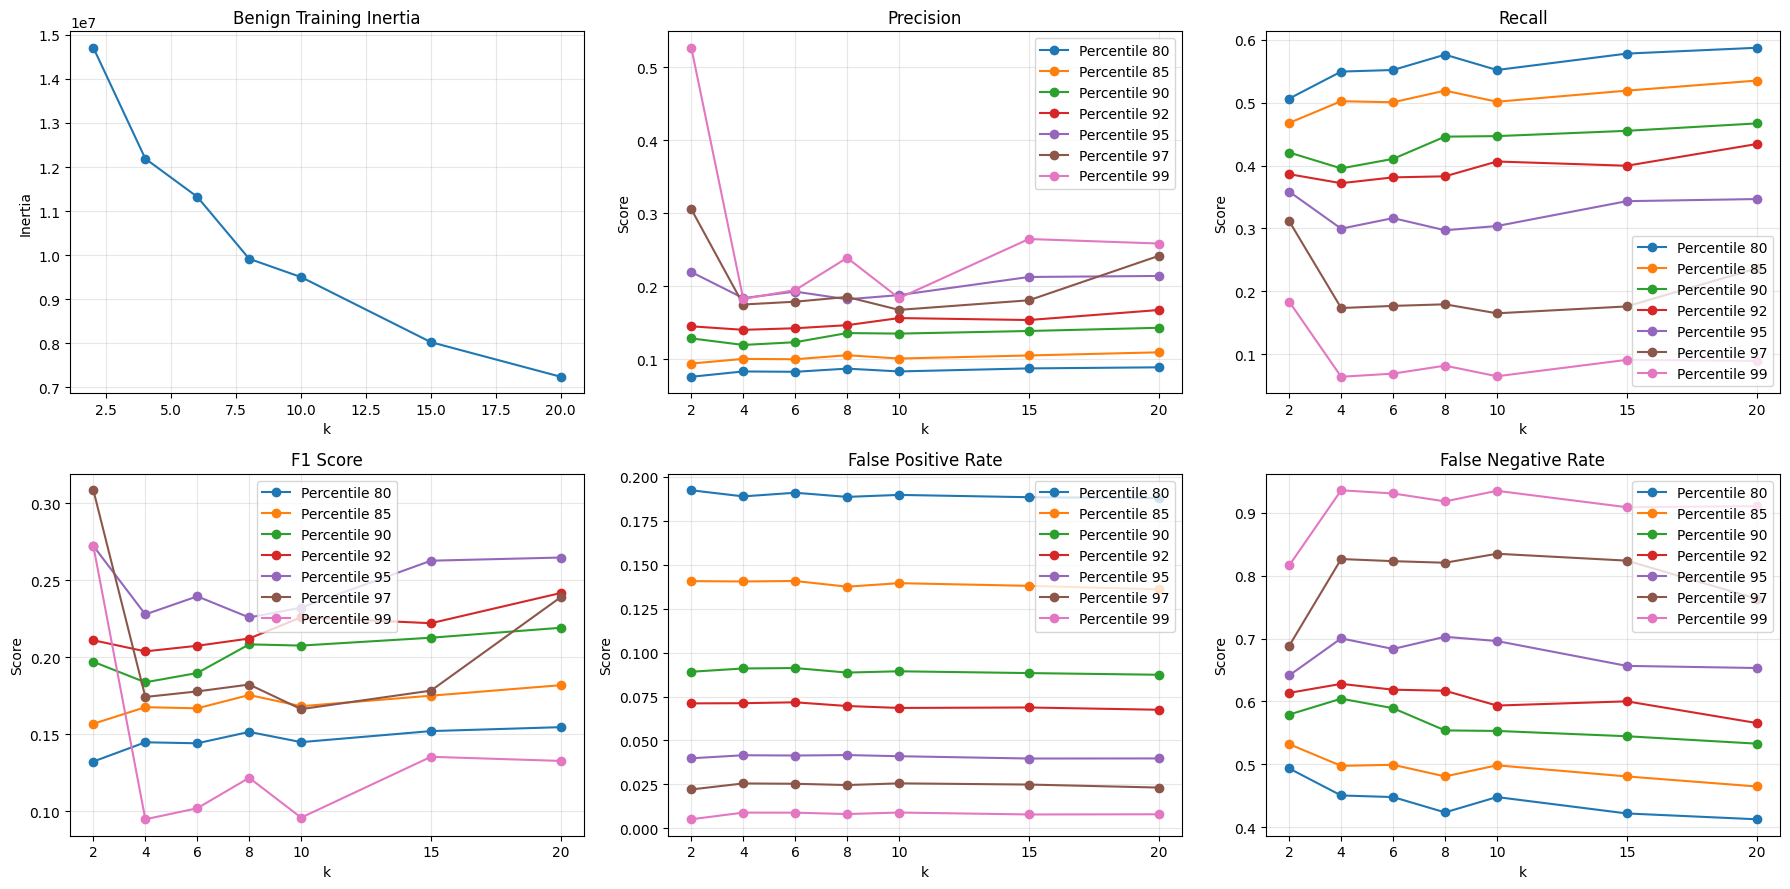

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

# Plot inertia to show how well the model fits the benign training data.
axes[0].plot(k_values, inertias, marker="o")
axes[0].set(title="Benign Training Inertia", xlabel="k", ylabel="Inertia")
axes[0].grid(alpha=0.3)

# Plot each metric for every threshold percentile.
for axis, metric, title in zip(
    axes[1:],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = kmeans_results_df[
            kmeans_results_df["threshold_percentile"] == percentile
        ].sort_values("k")
        axis.plot(
            subset["k"], subset[metric], marker="o", label=f"Percentile {percentile}"
        )
    axis.set(title=title, xlabel="k", ylabel="Score")
    axis.set_xticks(k_values)
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

# Autoencoders (high-recall alert generator)

### Autoencoders Hyperparameters Tuning

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score)

keras.utils.set_random_seed(Seed)

bottleneck_sizes = [2, 4, 8, 16, 32]
threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

# Fit the autoencoder on unlabeled training features.
X_benign_train_ae = X_train_scaled.astype(np.float32)
X_evaluation_ae = X_validation_scaled.astype(np.float32)
y_evaluation_ae = y_validation
y_attack_ae = y_validation[y_validation != "benign"]
true_attack_ae = y_evaluation_ae != "benign"

input_dim = X_benign_train_ae.shape[1]
autoencoder_models = {}
ae_results = []

for bottleneck_size in bottleneck_sizes:
    keras.backend.clear_session()
    keras.utils.set_random_seed(Seed)

    inputs = keras.Input(shape=(input_dim,))
    encoded = keras.layers.Dense(64, activation="relu")(inputs)
    bottleneck = keras.layers.Dense(
        bottleneck_size, activation="relu", name="bottleneck"
    )(encoded)
    decoded = keras.layers.Dense(64, activation="relu")(bottleneck)
    outputs = keras.layers.Dense(input_dim)(decoded)
    autoencoder = keras.Model(inputs, outputs, name=f"autoencoder_{bottleneck_size}")
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    history = autoencoder.fit(
        X_benign_train_ae,
        X_benign_train_ae,
        epochs=50,
        batch_size=512,
        validation_split=0.1,
        shuffle=True,
        callbacks=[early_stopping],
        verbose=0,
    )
    autoencoder_models[bottleneck_size] = autoencoder
    print(f"Bottleneck {bottleneck_size}: trained for {len(history.history['loss'])} epochs")

    train_reconstruction = autoencoder.predict(X_benign_train_ae, verbose=0)
    train_errors = np.mean(
        (X_benign_train_ae - train_reconstruction) ** 2, axis=1
    )
    evaluation_reconstruction = autoencoder.predict(X_evaluation_ae, verbose=0)
    evaluation_errors = np.mean(
        (X_evaluation_ae - evaluation_reconstruction) ** 2, axis=1
    )

    for percentile in threshold_percentiles:
        threshold = np.percentile(train_errors, percentile)
        predicted_attack = evaluation_errors > threshold

        precision = precision_score(
            true_attack_ae, predicted_attack, zero_division=0
        )
        f1 = f1_score(true_attack_ae, predicted_attack, zero_division=0)
        recall = recall_score(true_attack_ae, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack_ae, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        result = {
            "bottleneck_size": bottleneck_size,
            "threshold_percentile": percentile,
            "threshold": threshold,
            "precision": precision,
            "f1": f1,
            "recall": recall,
            "fpr": fpr,
            "fnr": fnr,
        }
        ae_results.append(result)

        print(
            f"bottleneck={bottleneck_size}, percentile={percentile}: "
            f"Precision={precision:.4f}, Recall={recall:.4f}, "
            f"F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack_ae)):
            attack_mask = y_evaluation_ae == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

ae_results_df = pd.DataFrame(ae_results)
display(
    ae_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

# Select on validation data: prioritize recall, then control false alarms.
eligible_ae = ae_results_df[
    (ae_results_df["recall"] >= 0.80) & (ae_results_df["fpr"] <= 0.10)
]
if eligible_ae.empty:
    eligible_ae = ae_results_df[ae_results_df["fpr"] <= 0.10]
if eligible_ae.empty:
    eligible_ae = ae_results_df
best_ae_config = eligible_ae.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]
best_bottleneck_size = int(best_ae_config["bottleneck_size"])
best_ae_percentile = int(best_ae_config["threshold_percentile"])
best_autoencoder = autoencoder_models[best_bottleneck_size]
best_ae_threshold = float(best_ae_config["threshold"])

X_test_ae = X_test_scaled.astype(np.float32)
ae_test_reconstruction = best_autoencoder.predict(X_test_ae, verbose=0)
ae_test_scores = np.mean((X_test_ae - ae_test_reconstruction) ** 2, axis=1)
ae_test_predictions = ae_test_scores > best_ae_threshold
ae_test_truth = y_test != "benign"
ae_test_precision = precision_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_test_recall = recall_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_test_f1 = f1_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_tn, ae_fp, ae_fn, ae_tp = confusion_matrix(
    ae_test_truth, ae_test_predictions, labels=[False, True]
).ravel()
ae_test_fpr = ae_fp / (ae_fp + ae_tn)
ae_test_fnr = ae_fn / (ae_fn + ae_tp)
ae_test_roc_auc = roc_auc_score(ae_test_truth, ae_test_scores)
ae_test_pr_auc = average_precision_score(ae_test_truth, ae_test_scores)
print(
    f"Final autoencoder test: bottleneck={best_bottleneck_size}, "
    f"percentile={best_ae_percentile}, Precision={ae_test_precision:.4f}, "
    f"Recall={ae_test_recall:.4f}, F1={ae_test_f1:.4f}, "
    f"FPR={ae_test_fpr:.4f}, FNR={ae_test_fnr:.4f}, "
    f"ROC-AUC={ae_test_roc_auc:.4f}, PR-AUC={ae_test_pr_auc:.4f}"
)
print(np.array([[ae_tp, ae_fp], [ae_fn, ae_tn]]))
for attack in sorted(np.unique(y_test[y_test != "benign"])):
    attack_mask = y_test == attack
    print(f"  {attack} detection rate: {ae_test_predictions[attack_mask].mean():.4f}")

autoencoder_alerts_df = pd.DataFrame({
    "packet_id": packet_ids.iloc[index_test].to_numpy(),
    "true_label": y_test,
    "anomaly_score": ae_test_scores,
    "alert": ae_test_predictions,
})
autoencoder_alerts_df = autoencoder_alerts_df[
    autoencoder_alerts_df["alert"]
].reset_index(drop=True)

Bottleneck 2: trained for 50 epochs
bottleneck=2, percentile=80: Precision=0.0843, Recall=0.5623, F1=0.1466
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  668  7258]
 [  520 30742]]
  brute_force detection rate: 0.2827
  ddos detection rate: 0.9030
  dns_spoofing detection rate: 0.4244
  dos detection rate: 0.9118
  xss detection rate: 0.2899
bottleneck=2, percentile=85: Precision=0.1040, Recall=0.5210, F1=0.1734
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  619  5334]
 [  569 32666]]
  brute_force detection rate: 0.2532
  ddos detection rate: 0.8397
  dns_spoofing detection rate: 0.3613
  dos detection rate: 0.9034
  xss detection rate: 0.2479
bottleneck=2, percentile=90: Precision=0.1369, Recall=0.4529, F1=0.2102
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  538  3393]
 [  650 34607]]

,bottleneck_size,threshold_percentile,threshold,precision,f1,recall,fpr,fnr
0,32,80,0.043397,0.102524,0.177718,0.666667,0.182447,0.333333
1,16,80,0.063744,0.101227,0.175529,0.659933,0.183184,0.340067
2,8,80,0.101889,0.093221,0.161971,0.617003,0.187632,0.382997
3,32,85,0.050294,0.125434,0.207949,0.607744,0.132474,0.392256
4,16,85,0.073220,0.122425,0.203654,0.605219,0.135632,0.394781
5,4,80,0.144883,0.085329,0.148432,0.569865,0.190974,0.430135
6,8,85,0.121103,0.114452,0.190287,0.563973,0.136421,0.436027
7,2,80,0.268357,0.084280,0.146588,0.562290,0.191000,0.437710
8,16,90,0.089207,0.169743,0.259384,0.549663,0.084053,0.450337
9,32,90,0.061922,0.169866,0.258866,0.543771,0.083079,0.456229


Final autoencoder test: bottleneck=16, percentile=90, Precision=0.1641, Recall=0.5455, F1=0.2522, FPR=0.0869, FNR=0.4545, ROC-AUC=0.8067, PR-AUC=0.2407
[[  648  3302]
 [  540 34698]]
  brute_force detection rate: 0.1891
  ddos detection rate: 0.7521
  dns_spoofing detection rate: 0.5949
  dos detection rate: 0.9286
  xss detection rate: 0.2616


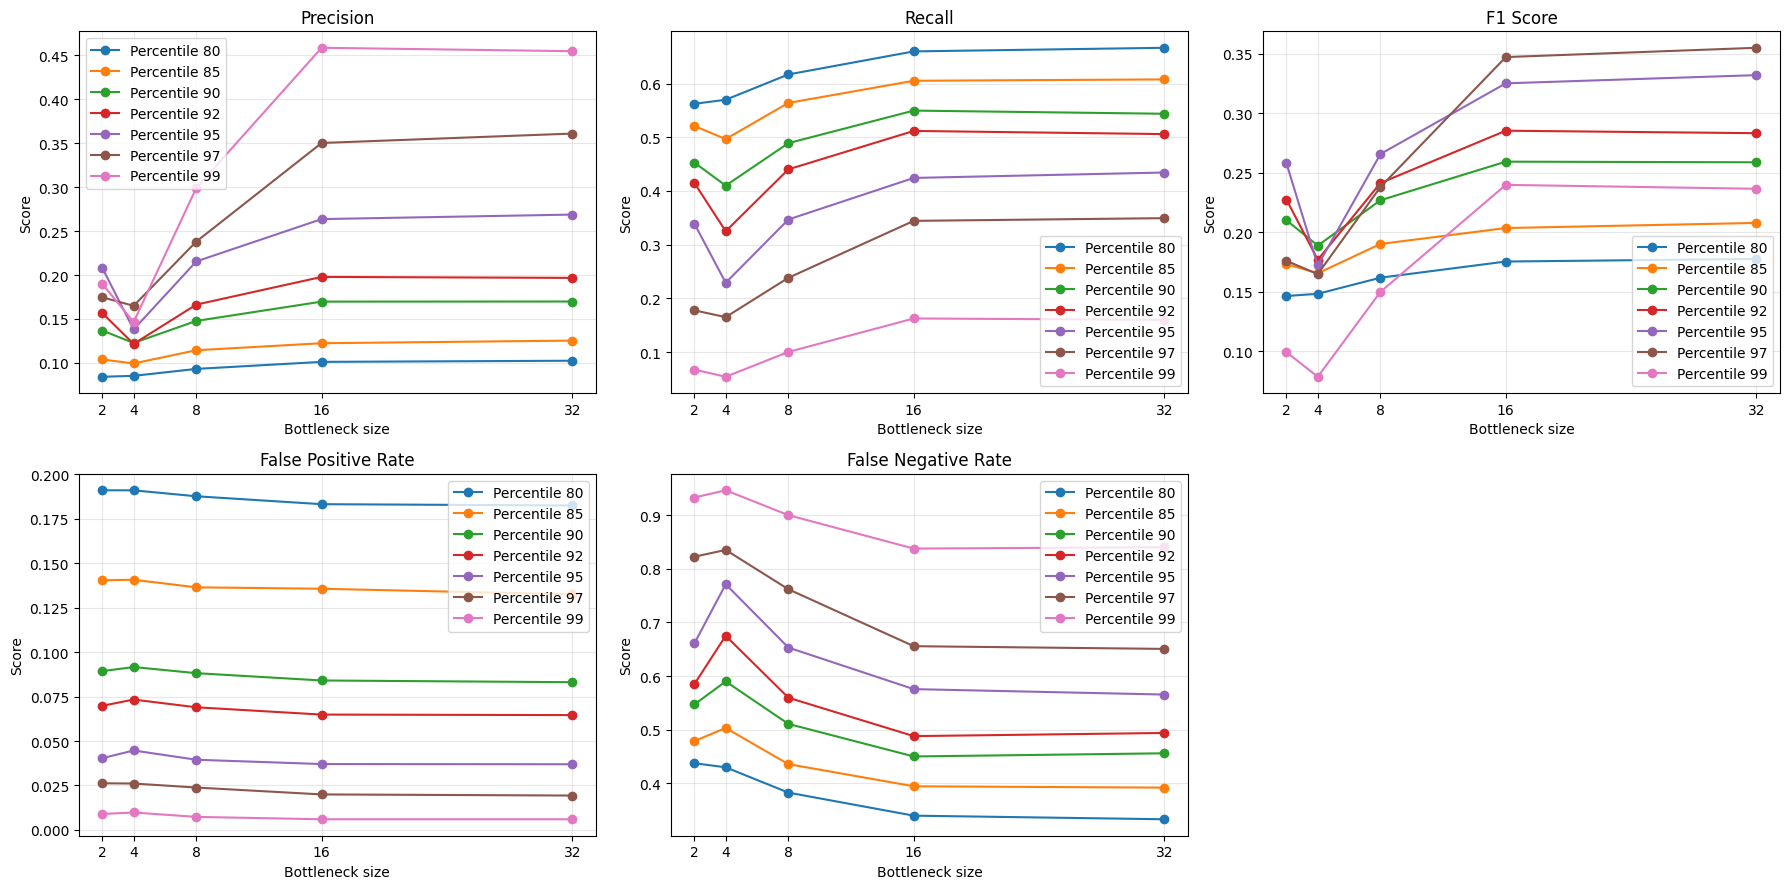

In [78]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for axis, metric, title in zip(
    axes[:5],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = ae_results_df[
            ae_results_df["threshold_percentile"] == percentile
        ].sort_values("bottleneck_size")
        axis.plot(
            subset["bottleneck_size"],
            subset[metric],
            marker="o",
            label=f"Percentile {percentile}",
        )
    axis.set(title=title, xlabel="Bottleneck size", ylabel="Score")
    axis.set_xticks(bottleneck_sizes)
    axis.grid(alpha=0.3)
    axis.legend()

axes[5].axis("off")
plt.tight_layout()
plt.show()

### Final Phase 2 Test Curves

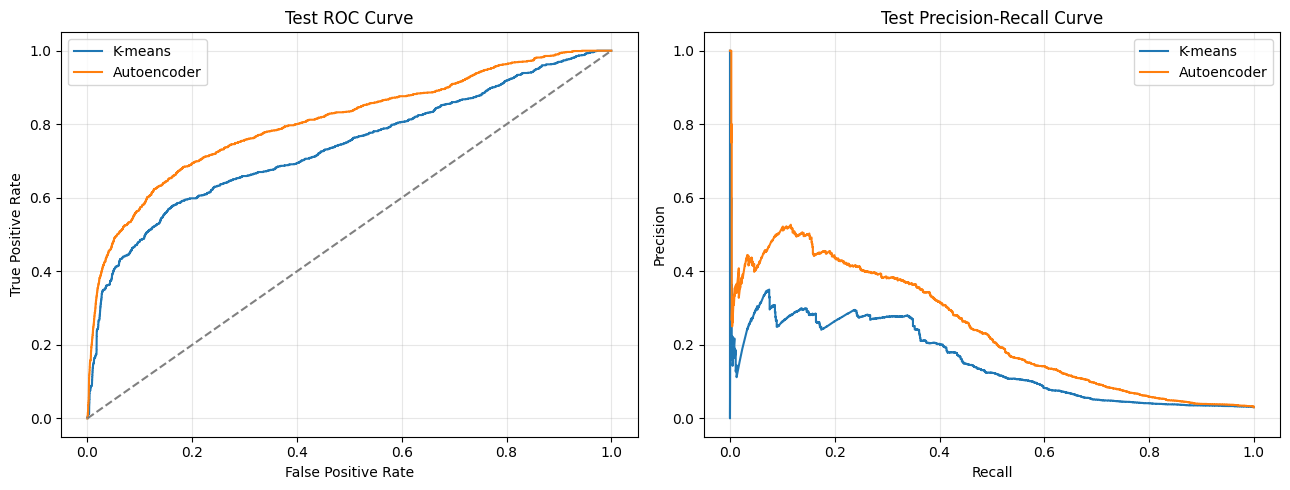

In [79]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, scores in [
    ("K-means", kmeans_test_scores),
    ("Autoencoder", ae_test_scores),
]:
    fpr_curve, tpr_curve, _ = roc_curve(ae_test_truth, scores)
    curve_precision, curve_recall, _ = precision_recall_curve(ae_test_truth, scores)
    axes[0].plot(fpr_curve, tpr_curve, label=name)
    axes[1].plot(curve_recall, curve_precision, label=name)

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="Test ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].set(title="Test Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()